In [2]:
import pandas as pd
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random 
from latent_regularizer import*

In [3]:
def draw_gmm_samples(num_samples, gmm_centers, gmm_std):
    num_gmm_centers, dimension = gmm_centers.shape
    print(num_gmm_centers, dimension)
    samples = []
    components = []
    for _ in range(num_samples):
        component = np.random.choice(range(num_gmm_centers))

        component_mean = gmm_centers[component, :]
        component_cov = torch.eye(dimension) * gmm_std

        distribution = torch.distributions.multivariate_normal.MultivariateNormal(
            loc=component_mean, covariance_matrix=component_cov)

        sample = distribution.sample((1,))
        samples.append(sample)
        components.append(component)
    samples = torch.vstack(samples)

    return samples, components

In [4]:
def generate_5_gmm_centers(num_pairs, range_start):
    import random
    unique_pairs = []
    for _ in range(num_pairs):
        num1 = random.uniform(range_start, range_start+6)
        num2 = random.uniform(range_start+6, range_start+12)
        num3 = random.uniform(range_start+12, range_start+18)
        num4 = random.uniform(range_start+18, range_start+24)
        num5 = random.uniform(range_start+30, range_start+36)
        unique_pairs.append((num1, num2, num3, num4, num5))
    gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
    return gmm_centers

[[-20.243214 ]
 [-13.938308 ]
 [ -5.6595273]
 [ -0.763898 ]
 [  9.531951 ]]
Standard deviation used: 6
5 1


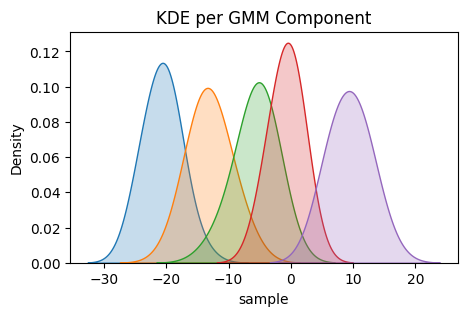

In [5]:
batch_size = 128
num_samples = 100
def gaussian_sample(num_samples):
    startpoint = random.randint(-30,0)
    gmm_centers = generate_5_gmm_centers(1, startpoint)
    print(gmm_centers.numpy())
    gmm_std=6
    print(f"Standard deviation used: {gmm_std}")
    samples, components = draw_gmm_samples(num_samples, gmm_centers, gmm_std)
    data = samples.numpy()
    df = pd.DataFrame({'sample': data[:, 0], 'component': components})
    plt.figure(figsize=(5, 3))
    for comp_id in sorted(df['component'].unique()):
        subset = df[df['component'] == comp_id]
        sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
    plt.title("KDE per GMM Component")
    plt.show()
    return gmm_centers.numpy(), df, gmm_std
gmm_center, temp_data, gmm_std = gaussian_sample(num_samples)

[[-25.5769  ]
 [-21.387688]
 [-15.655427]
 [ -4.758278]
 [  4.710046]]
Standard deviation used: 2
5 1


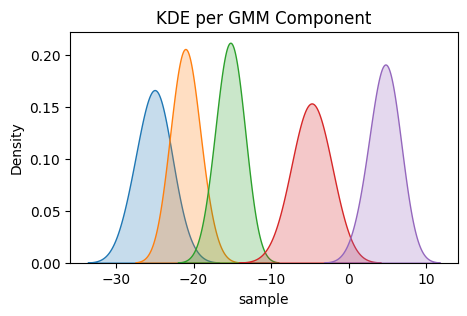

[[-15.239411]
 [-10.431845]
 [ -1.600438]
 [  6.015052]
 [ 13.041493]]
Standard deviation used: 2
5 1


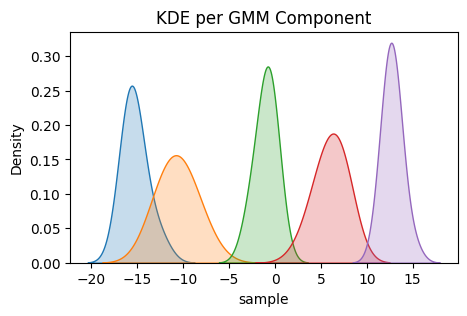

In [40]:
gmm_centers_dim1, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim2, df, gmm_std = gaussian_sample(num_samples)
df_gmm_centers_rand = pd.DataFrame(np.squeeze([gmm_centers_dim1, gmm_centers_dim2], axis=-1), columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_rand
df_gmm_centers_rand.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_rand_5.csv')

[[-1.9922627]
 [ 2.3115442]
 [ 9.777489 ]
 [17.319899 ]
 [24.772062 ]]
Standard deviation used: 2
5 1


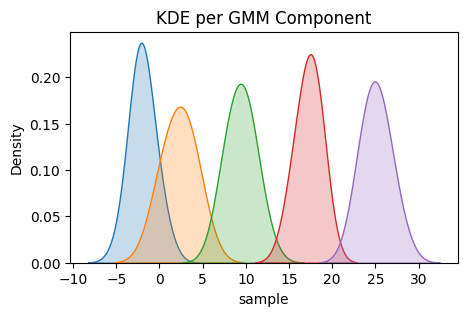

In [92]:
gmm_centers_dim2, df, gmm_std = gaussian_sample(num_samples)

In [93]:
df_gmm_centers_rand = pd.DataFrame(np.squeeze([gmm_centers_dim1, gmm_centers_dim2], axis=-1), columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_rand

,center1,center2,center3,center4,center5
0,-25.576900,-21.387688,-15.655427,-4.758278,4.710046
1,-1.992263,2.311544,9.777489,17.319899,24.772062


In [94]:
df_gmm_centers_rand.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_rand_6.csv')

In [ ]:
df_gmm_centers_box = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_box
df_gmm_centers_box.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box.csv')

In [525]:
gmm_centers_5_new = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_six.csv')
gmm_centers_5_new.values[:, 1:]

array([[-4., -2.,  0.,  2.,  4.],
       [-4., -2.,  0.,  2.,  4.]])

In [526]:
gmm_centers_5_new_np = torch.tensor(list(zip(*gmm_centers_5_new.values[:, 1:]))).float()

5 2
(128, 2)


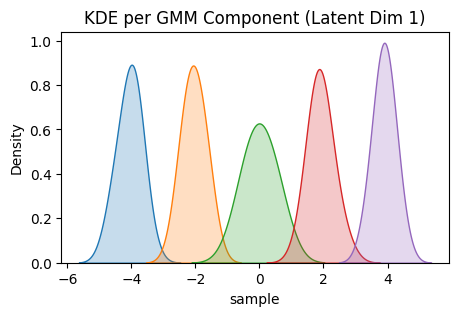

In [536]:
gmm_centers = gmm_centers_5_new_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


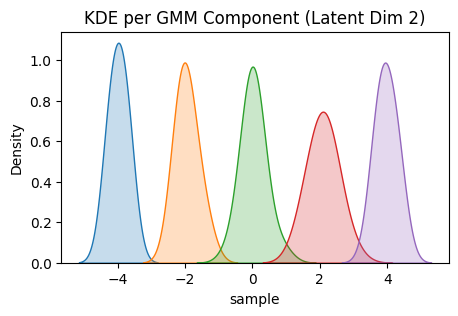

In [537]:
gmm_centers = gmm_centers_5_new_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 2)")
plt.show()

In [474]:
df_gmm_centers = pd.DataFrame(gmm_centers.T, columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_two.csv')

In [538]:
df_gmm_centers

,center1,center2,center3,center4,center5
0,-1.333333,-0.666667,0.0,0.666667,1.333333
1,-1.333333,-0.666667,0.0,0.666667,1.333333


In [126]:
center_0 = [-8, -8, 0, 8, 8]
center_1 = [-8, 8, 0, -8, 8]
df_gmm_centers_box = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_box
df_gmm_centers_box.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box_small.csv')

In [127]:
gmm_centers_5_box_np = torch.tensor(list(zip(*df_gmm_centers_box.values))).float()
gmm_centers_5_box_np

tensor([[-8., -8.],
        [-8.,  8.],
        [ 0.,  0.],
        [ 8., -8.],
        [ 8.,  8.]])

5 2
(128, 2)


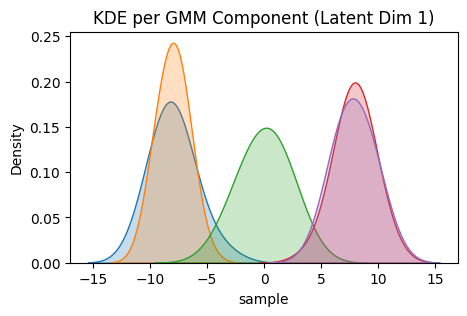

In [137]:
gmm_centers = gmm_centers_5_box_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


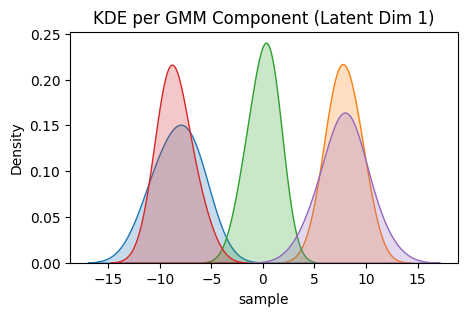

In [136]:
gmm_centers = gmm_centers_5_box_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

In [111]:
center_0 = [-20, 0, -15, 15, 20]
center_1 = [-15, -20, 15, 0, 20]
df_gmm_centers_zigzag = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_zigzag

,center1,center2,center3,center4,center5
0,-20,0,-15,15,20
1,-15,-20,15,0,20


In [112]:
df_gmm_centers_zigzag_np = torch.tensor(list(zip(*df_gmm_centers_zigzag.values))).float()
df_gmm_centers_zigzag_np

tensor([[-20., -15.],
        [  0., -20.],
        [-15.,  15.],
        [ 15.,   0.],
        [ 20.,  20.]])

5 2
(128, 2)


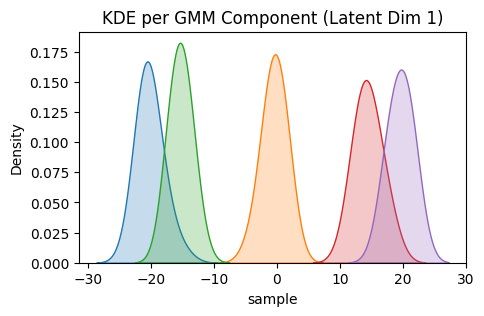

In [113]:
gmm_centers = df_gmm_centers_zigzag_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


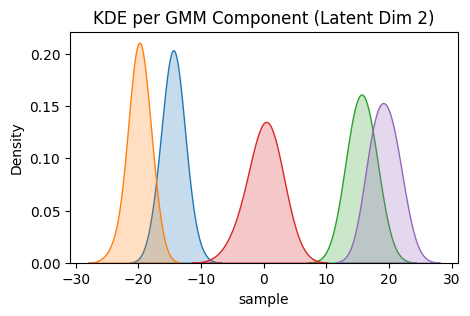

In [114]:
gmm_centers = df_gmm_centers_zigzag_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 2)")
plt.show()

[[-11.628119 ]
 [ -6.8772407]
 [ -0.9386234]
 [  8.212272 ]
 [ 16.051737 ]]
Standard deviation used: 6
5 1


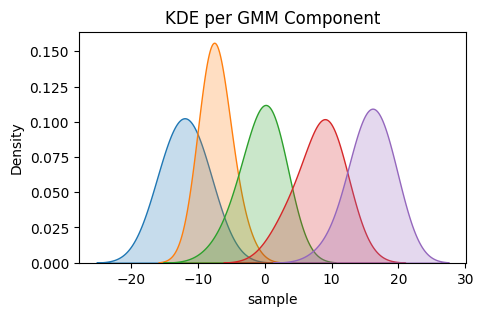

[[ 1.4852597]
 [ 6.8273754]
 [17.550583 ]
 [23.266594 ]
 [30.86456  ]]
Standard deviation used: 6
5 1


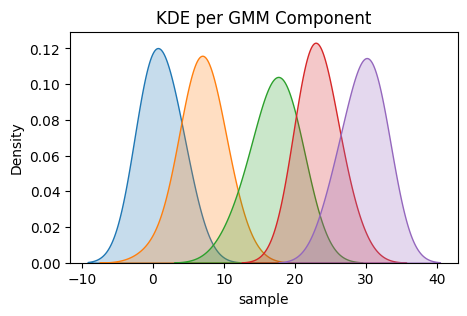

[[-21.57466 ]
 [-17.941076]
 [ -8.181978]
 [ -7.649382]
 [  9.391999]]
Standard deviation used: 6
5 1


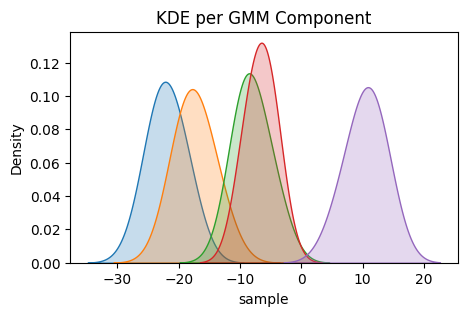

[[-9.361098 ]
 [-1.9375414]
 [ 5.646889 ]
 [10.705423 ]
 [19.36859  ]]
Standard deviation used: 6
5 1


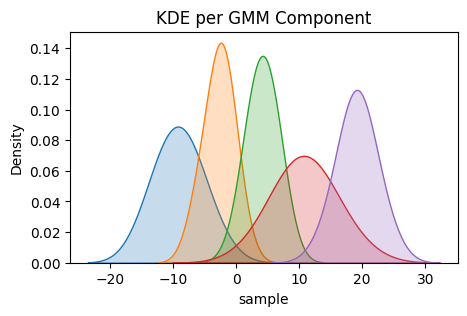

[[-17.637957  ]
 [-11.392148  ]
 [ -5.589405  ]
 [  0.24682541]
 [ 12.808093  ]]
Standard deviation used: 6
5 1


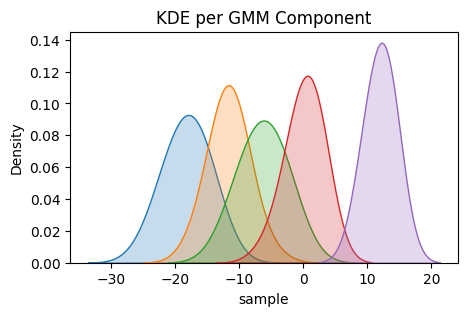

,center1,center2,center3,center4,center5
0,-11.628119,-6.877241,-0.938623,8.212272,16.051737
1,1.485260,6.827375,17.550583,23.266594,30.864559
2,-21.574659,-17.941076,-8.181978,-7.649382,9.391999
3,-9.361098,-1.937541,5.646889,10.705423,19.368589
4,-17.637957,-11.392148,-5.589405,0.246825,12.808093


In [149]:
gmm_centers_dim1, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim2, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim3, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim4, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim5, df, gmm_std = gaussian_sample(num_samples)
df_gmm_centers_5dim = pd.DataFrame(np.squeeze([gmm_centers_dim1, gmm_centers_dim2, gmm_centers_dim3, gmm_centers_dim4, gmm_centers_dim5], axis=-1), columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_5dim

In [147]:
df_gmm_centers_5dim.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5dim_V2.csv')

[[-0.81830096]
 [ 8.320318  ]
 [13.140818  ]
 [16.661285  ]
 [30.682468  ]]
Standard deviation used: 6
5 1


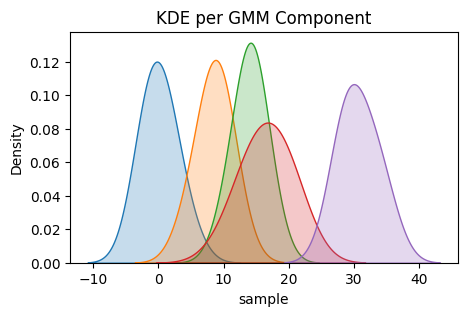

[[-14.4640045]
 [ -5.5784616]
 [ -0.674281 ]
 [  6.7801676]
 [ 16.087563 ]]
Standard deviation used: 6
5 1


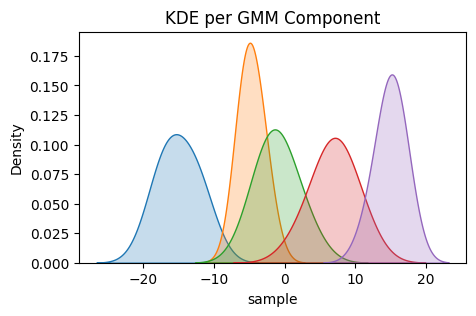

[[-3.5504544 ]
 [ 0.08761305]
 [ 8.577321  ]
 [14.411488  ]
 [25.82279   ]]
Standard deviation used: 6
5 1


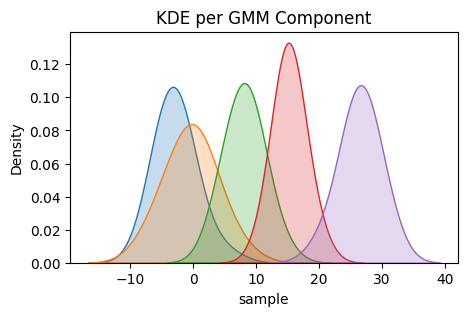

[[-4.2239203]
 [ 5.7875333]
 [ 9.039777 ]
 [13.439266 ]
 [30.550634 ]]
Standard deviation used: 6
5 1


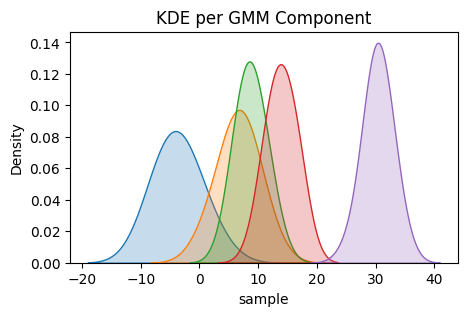

[[-6.907713 ]
 [-2.578547 ]
 [ 4.4885445]
 [12.040833 ]
 [23.308147 ]]
Standard deviation used: 6
5 1


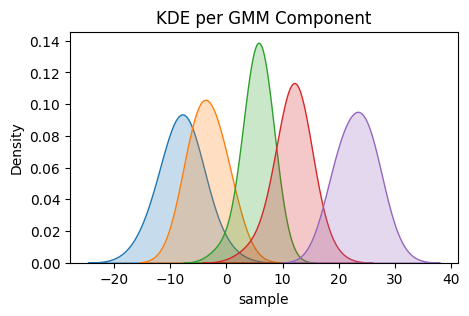

[[-23.33248 ]
 [-19.797367]
 [-14.854468]
 [ -8.187571]
 [  5.430047]]
Standard deviation used: 6
5 1


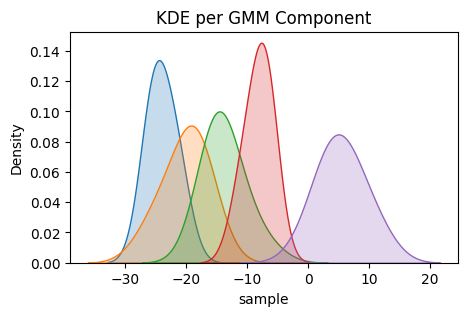

[[-11.534334 ]
 [ -9.60793  ]
 [ -1.4236465]
 [  1.2213258]
 [ 16.300383 ]]
Standard deviation used: 6
5 1


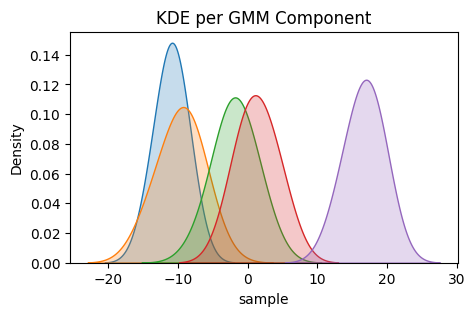

[[ 2.3409288]
 [ 5.5910816]
 [ 9.391351 ]
 [18.168602 ]
 [27.056824 ]]
Standard deviation used: 6
5 1


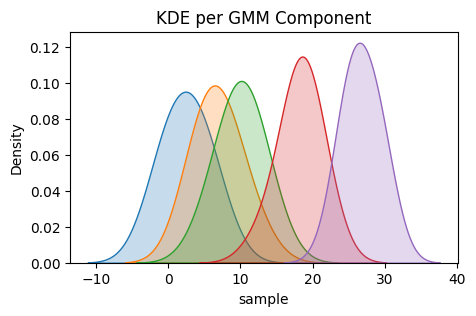

[[-3.2857058]
 [ 5.7548566]
 [ 9.201128 ]
 [19.72473  ]
 [30.682928 ]]
Standard deviation used: 6
5 1


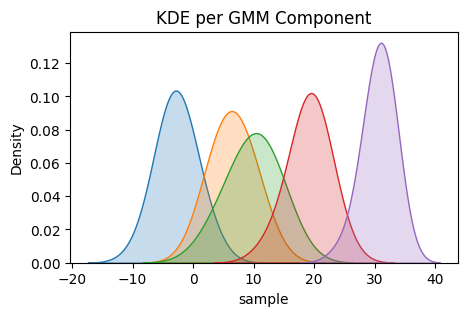

[[ 0.15737987]
 [ 6.345616  ]
 [13.141832  ]
 [17.241549  ]
 [32.400948  ]]
Standard deviation used: 6
5 1


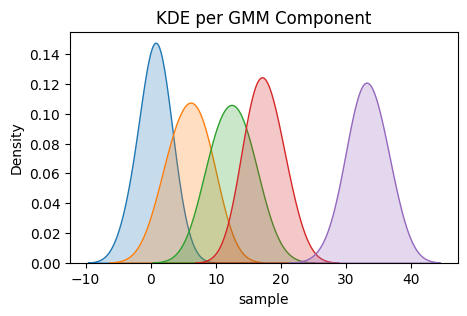

[[-24.409866 ]
 [-19.810669 ]
 [-13.05404  ]
 [ -7.5194254]
 [  4.716182 ]]
Standard deviation used: 6
5 1


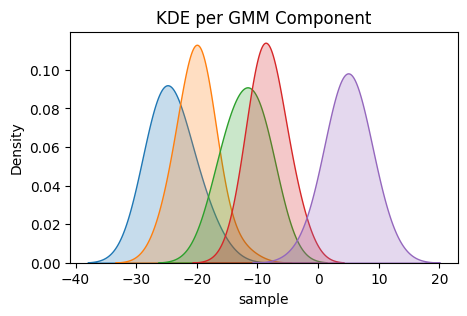

[[-17.548265 ]
 [ -8.052634 ]
 [ -7.586599 ]
 [  3.3758495]
 [ 13.517798 ]]
Standard deviation used: 6
5 1


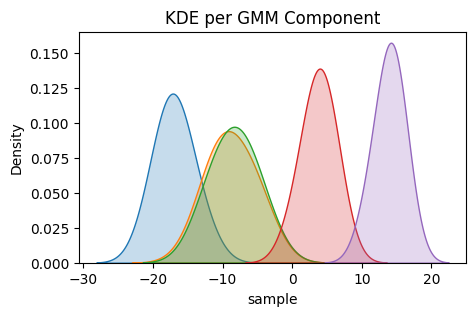

[[ 3.2511132]
 [ 5.3403153]
 [15.108034 ]
 [19.871244 ]
 [30.587875 ]]
Standard deviation used: 6
5 1


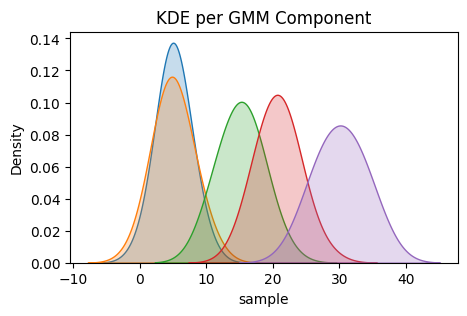

[[-3.4759142 ]
 [-0.11404654]
 [ 9.258525  ]
 [10.386569  ]
 [27.245094  ]]
Standard deviation used: 6
5 1


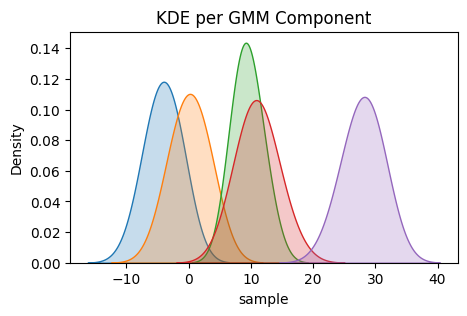

[[-15.766488  ]
 [ -8.130376  ]
 [ -0.06705333]
 [  3.5419612 ]
 [ 13.517368  ]]
Standard deviation used: 6
5 1


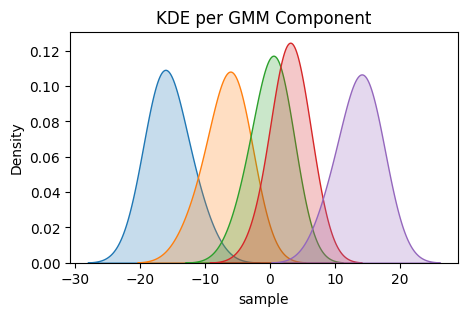

[[-1.28282  ]
 [ 3.902691 ]
 [10.0824375]
 [11.442588 ]
 [25.956116 ]]
Standard deviation used: 6
5 1


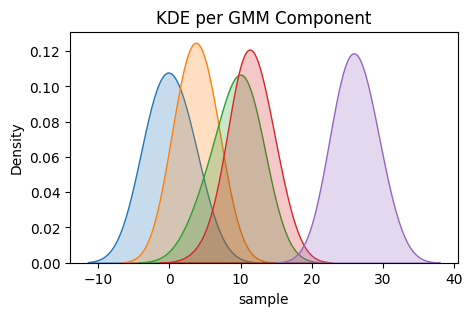

[[-2.590755 ]
 [ 2.6575336]
 [12.840919 ]
 [15.986624 ]
 [29.53588  ]]
Standard deviation used: 6
5 1


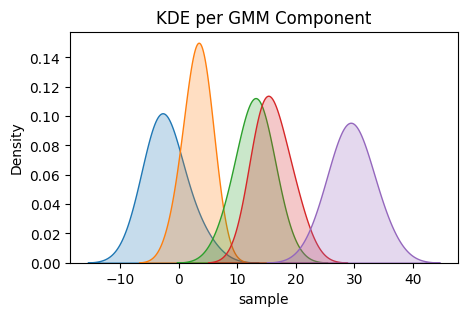

[[-18.003391 ]
 [-10.411867 ]
 [ -4.0022016]
 [  2.2767134]
 [ 11.804743 ]]
Standard deviation used: 6
5 1


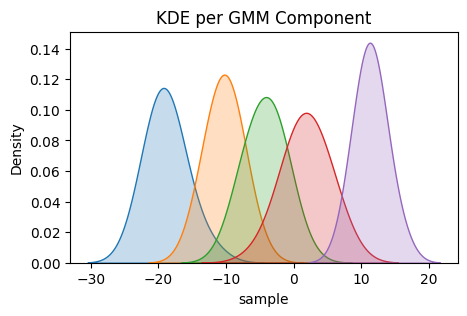

[[-29.327963  ]
 [-23.879192  ]
 [-12.47407   ]
 [ -6.234708  ]
 [  0.48812053]]
Standard deviation used: 6
5 1


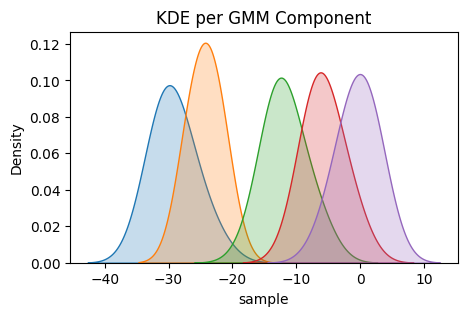

[[-22.341265 ]
 [-21.421131 ]
 [-12.810738 ]
 [ -4.0400577]
 [  7.644705 ]]
Standard deviation used: 6
5 1


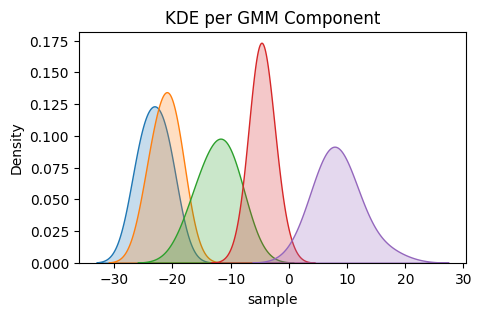

[[-24.964956 ]
 [-16.243645 ]
 [-10.324132 ]
 [ -5.736851 ]
 [  3.2696967]]
Standard deviation used: 6
5 1


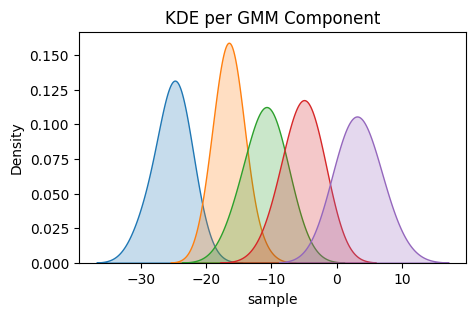

[[-18.291677  ]
 [-13.915656  ]
 [ -8.795943  ]
 [ -0.35943383]
 [  8.624991  ]]
Standard deviation used: 6
5 1


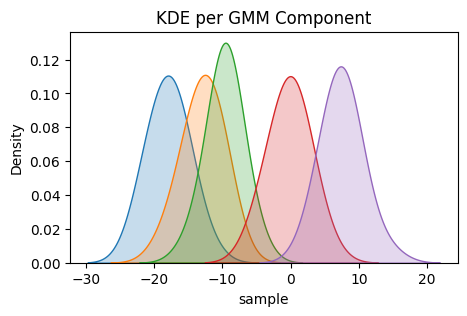

[[-5.4980993]
 [-1.642178 ]
 [ 6.79986  ]
 [10.94237  ]
 [24.76177  ]]
Standard deviation used: 6
5 1


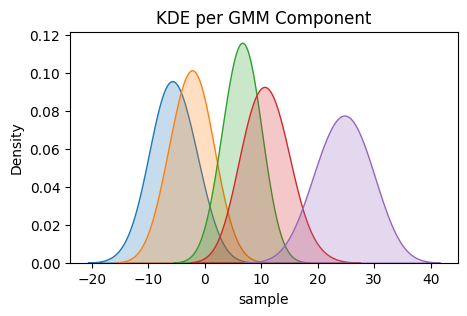

[[-19.087467 ]
 [-16.231285 ]
 [-12.635679 ]
 [ -2.1616912]
 [  6.305582 ]]
Standard deviation used: 6
5 1


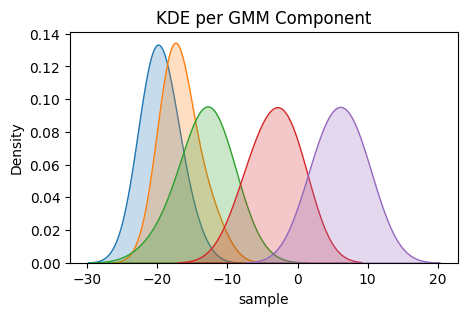

[[ 3.5788698]
 [ 6.6054206]
 [11.702718 ]
 [19.540136 ]
 [30.088564 ]]
Standard deviation used: 6
5 1


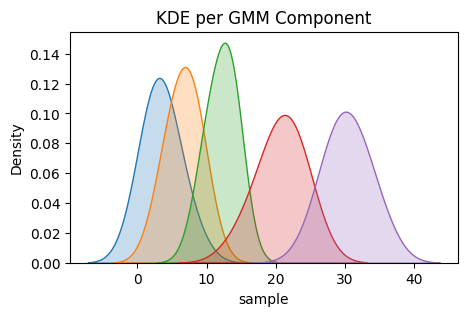

[[-18.265162 ]
 [-14.399036 ]
 [ -6.0305886]
 [ -3.1930096]
 [ 12.880802 ]]
Standard deviation used: 6
5 1


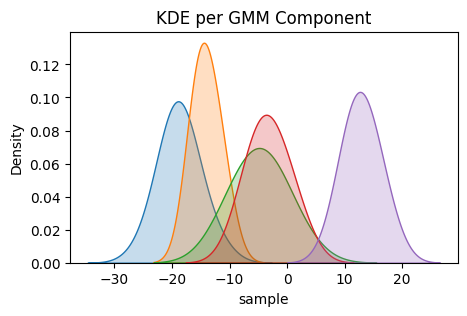

[[-7.303829 ]
 [-2.5697064]
 [ 3.0853655]
 [10.4903145]
 [22.006243 ]]
Standard deviation used: 6
5 1


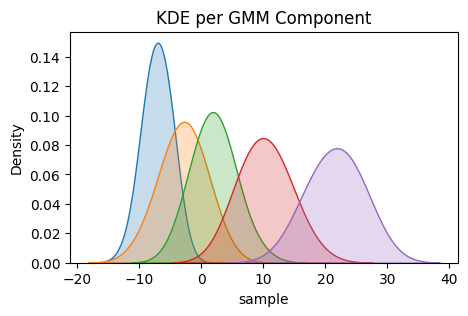

[[-17.351738 ]
 [-13.0289755]
 [ -7.5877585]
 [ -3.0080352]
 [ 11.024121 ]]
Standard deviation used: 6
5 1


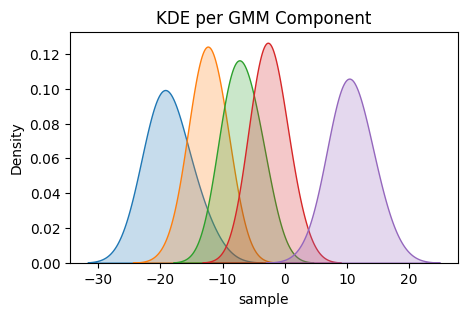

[[-10.758409 ]
 [ -2.2810736]
 [  1.4960339]
 [  8.065338 ]
 [ 24.047485 ]]
Standard deviation used: 6
5 1


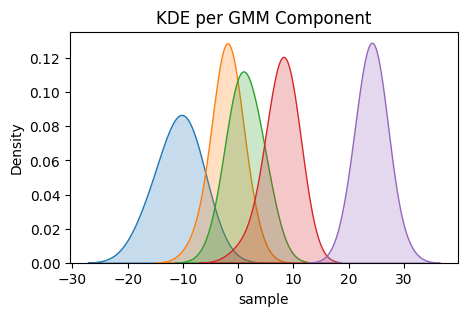

[[-14.220214  ]
 [ -9.876138  ]
 [ -0.44881168]
 [  1.6947676 ]
 [ 12.306955  ]]
Standard deviation used: 6
5 1


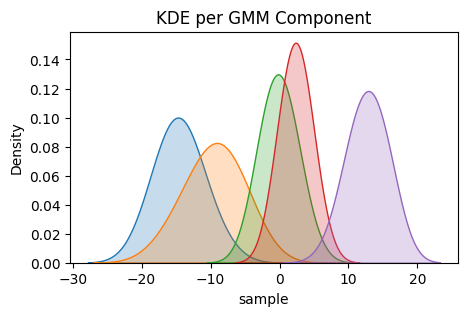

[[-1.1728771e+01]
 [-5.3758550e+00]
 [ 1.3834220e-02]
 [ 8.8318415e+00]
 [ 1.7474180e+01]]
Standard deviation used: 6
5 1


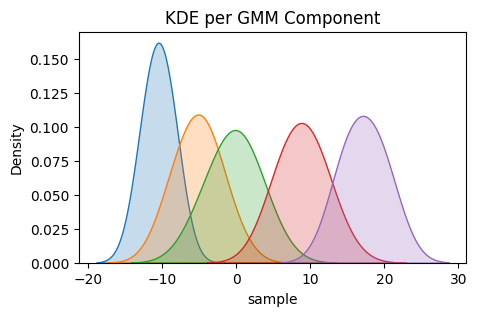

[[-8.874604 ]
 [-3.55302  ]
 [ 2.8804414]
 [ 9.11917  ]
 [23.105387 ]]
Standard deviation used: 6
5 1


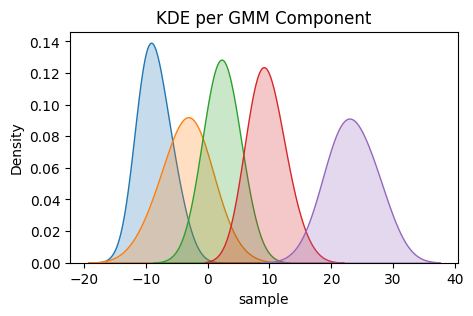

[[ 4.3318086]
 [11.67396  ]
 [15.574027 ]
 [18.539862 ]
 [30.07134  ]]
Standard deviation used: 6
5 1


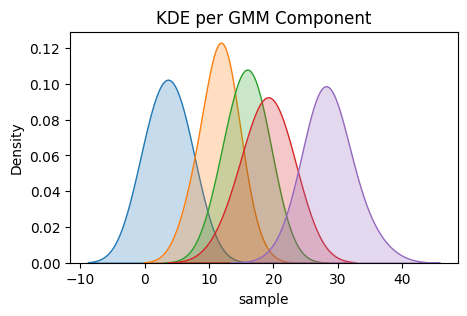

[[-22.410177 ]
 [-19.307589 ]
 [ -8.940557 ]
 [ -4.7897944]
 [  4.3328047]]
Standard deviation used: 6
5 1


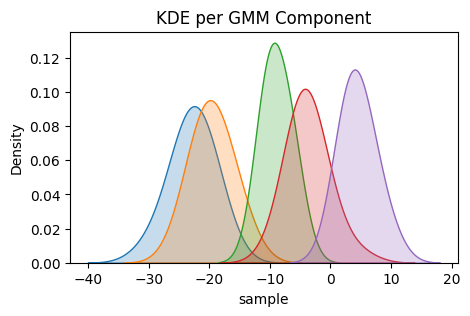

[[-11.130644 ]
 [ -7.0618057]
 [  2.1112165]
 [  4.5382442]
 [ 16.273933 ]]
Standard deviation used: 6
5 1


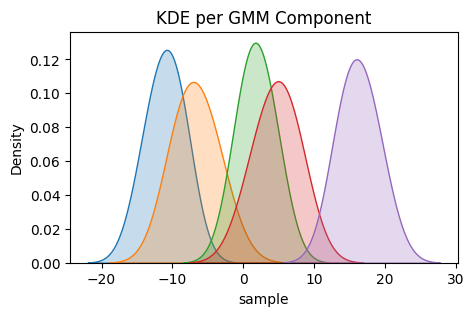

,center1,center2,center3,center4,center5
0,-0.818301,8.320318,13.140818,16.661285,30.682468
1,-14.464005,-5.578462,-0.674281,6.780168,16.087563
2,-3.550454,0.087613,8.577321,14.411488,25.822790
3,-4.223920,5.787533,9.039777,13.439266,30.550634
4,-6.907713,-2.578547,4.488544,12.040833,23.308147
5,-23.332479,-19.797367,-14.854468,-8.187571,5.430047
6,-11.534334,-9.607930,-1.423646,1.221326,16.300383
7,2.340929,5.591082,9.391351,18.168602,27.056824
8,-3.285706,5.754857,9.201128,19.724730,30.682928
9,0.157380,6.345616,13.141832,17.241549,32.400948


In [155]:
latent_dim = 35  # You can change this to 10, 20, or any number you want
num_centers = 5

all_centers = [] # An empty list to store the results

for _ in range(latent_dim):
    gmm_centers, _, _ = gaussian_sample(num_samples)
    all_centers.append(gmm_centers.T)

combined_centers = np.vstack(all_centers)

column_names = [f'center{i+1}' for i in range(num_centers)]

df_gmm_centers_35 = pd.DataFrame(combined_centers, columns=column_names)

df_gmm_centers_35

In [7]:
df_gmm_centers_35.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_10_dim.csv')

[[-15.638963 ]
 [ -9.8481865]
 [ -5.1215224]
 [ -1.5819292]
 [ 11.073133 ]]
Standard deviation used: 6
5 1


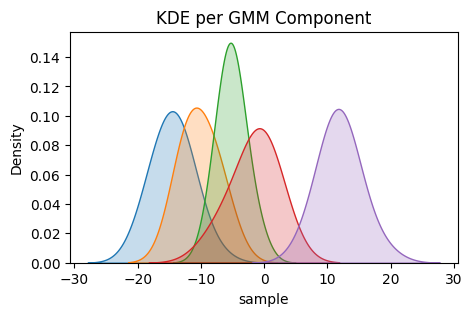

[[-0.04533617]
 [ 4.4550714 ]
 [12.700408  ]
 [20.117607  ]
 [29.32637   ]]
Standard deviation used: 6
5 1


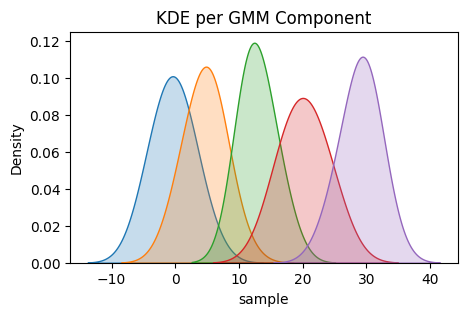

[[-26.10185  ]
 [-18.880705 ]
 [-13.7488575]
 [ -8.496363 ]
 [  4.188979 ]]
Standard deviation used: 6
5 1


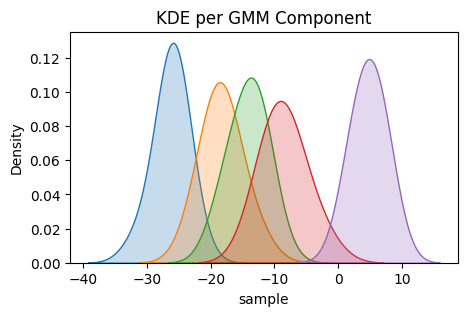

[[-5.455157  ]
 [ 0.32213336]
 [ 9.308972  ]
 [13.375928  ]
 [29.085173  ]]
Standard deviation used: 6
5 1


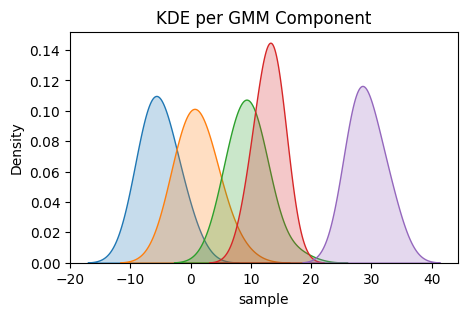

[[-1.9425301e+01]
 [-1.4426097e+01]
 [-6.0965676e+00]
 [-4.6504908e-03]
 [ 1.0714253e+01]]
Standard deviation used: 6
5 1


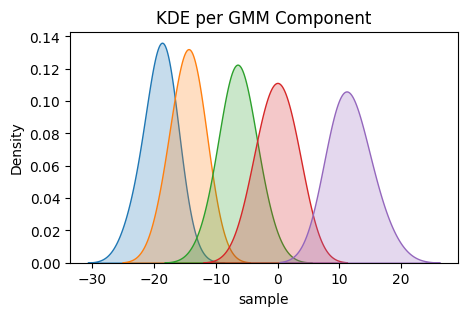

[[-20.90971  ]
 [-12.062491 ]
 [ -4.0212917]
 [  0.325825 ]
 [ 13.06772  ]]
Standard deviation used: 6
5 1


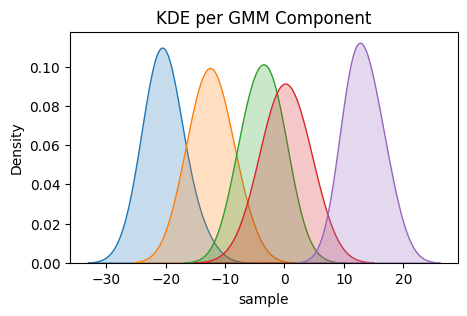

[[-8.179641 ]
 [-2.0684628]
 [ 7.8135185]
 [ 9.145989 ]
 [21.879528 ]]
Standard deviation used: 6
5 1


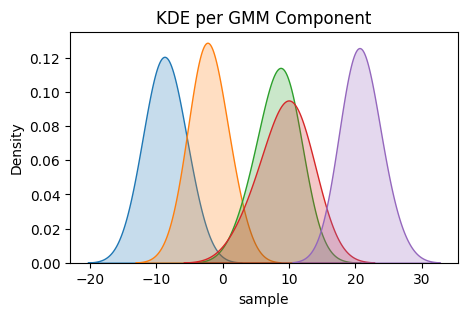

[[-15.880734 ]
 [ -8.678906 ]
 [ -5.4511347]
 [  4.901602 ]
 [ 16.313053 ]]
Standard deviation used: 6
5 1


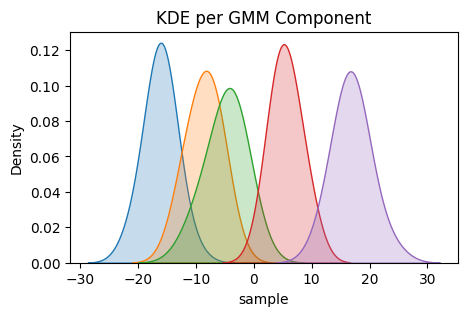

[[-3.6388655]
 [ 2.902999 ]
 [ 5.419694 ]
 [11.566309 ]
 [21.235922 ]]
Standard deviation used: 6
5 1


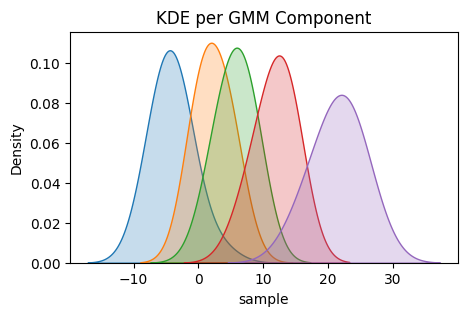

[[-13.90366  ]
 [ -6.9719095]
 [ -2.213154 ]
 [  4.689793 ]
 [ 15.520849 ]]
Standard deviation used: 6
5 1


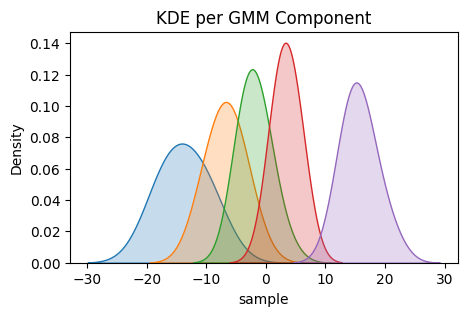

,center1,center2,center3,center4,center5
0,-15.638963,-9.848186,-5.121522,-1.581929,11.073133
1,-0.045336,4.455071,12.700408,20.117607,29.326370
2,-26.101851,-18.880705,-13.748857,-8.496363,4.188979
3,-5.455157,0.322133,9.308972,13.375928,29.085173
4,-19.425301,-14.426097,-6.096568,-0.004650,10.714253
5,-20.909710,-12.062491,-4.021292,0.325825,13.067720
6,-8.179641,-2.068463,7.813519,9.145989,21.879528
7,-15.880734,-8.678906,-5.451135,4.901602,16.313053
8,-3.638865,2.902999,5.419694,11.566309,21.235922
9,-13.903660,-6.971910,-2.213154,4.689793,15.520849


In [6]:
latent_dim = 10  # You can change this to 10, 20, or any number you want
num_centers = 5

all_centers = [] # An empty list to store the results

for _ in range(latent_dim):
    gmm_centers, _, _ = gaussian_sample(num_samples)
    all_centers.append(gmm_centers.T)

combined_centers = np.vstack(all_centers)

column_names = [f'center{i+1}' for i in range(num_centers)]

df_gmm_centers_35 = pd.DataFrame(combined_centers, columns=column_names)

df_gmm_centers_35